GitHub Link - https://github.com/MahendarReddyKongolla/Individual-Assignment-Machine-Learning.git

Dataset Link - https://www.kaggle.com/datasets/mohamedmaher5/vehicle-classification

# Tutorial Section: Dataset Setup and Loading

This section demonstrates how to download and prepare the dataset for a vehicle classification task.

KaggleHub API is used to ensure the dataset can be reproducibly accessed.

Download & Extract Dataset

In [1]:
# Import required libraries
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("mohamedmaher5/vehicle-classification")

print("Downloaded to:", path)

# The dataset contains a folder named "Vehicles" with class subfolders
DATASET_PATH = path + "/Vehicles"

# Verify dataset structure
print("Classes found:", os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'vehicle-classification' dataset.
Downloaded to: /kaggle/input/vehicle-classification
Classes found: ['Ships', 'Cars', 'Motorcycles', 'Bikes', 'Trains', 'Auto Rickshaws', 'Planes']


Load Dataset

In [2]:
# Import library for file operations
import shutil

# Define destination path
DEST_PATH = "/kaggle/working/vehicles_clean"

# Copy dataset to writable directory
if not os.path.exists(DEST_PATH):
    shutil.copytree(DATASET_PATH, DEST_PATH)

# Confirm copy location
print("Copied dataset to:", DEST_PATH)

# Update dataset path to new writable directory
DATASET_PATH = DEST_PATH

Copied dataset to: /kaggle/working/vehicles_clean


In [3]:
# Import library for image validation
from PIL import Image

# Function to clean dataset
def clean_dataset(directory):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

    removed = 0
    # Traverse all files in dataset
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            # Remove unsupported formats (like .webp)
            if not file.lower().endswith(valid_extensions):
                os.remove(file_path)
                removed += 1
                continue

            # Remove corrupted images
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)
                removed += 1

    print(f"Removed {removed} invalid/corrupted images")

# Run cleaning
clean_dataset(DATASET_PATH)

Removed 2 invalid/corrupted images


In [4]:
# Import TensorFlow
import tensorflow as tf

# Define image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset (80%)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset (20%)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract class names and number of classes
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

# Display classes
print("Classes:", CLASS_NAMES)

Found 5588 files belonging to 7 classes.
Using 4471 files for training.
Found 5588 files belonging to 7 classes.
Using 1117 files for validation.
Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


Data Preprocessing (Normalization & Optimization)



*   Scales pixel values to improve model convergence
*   Ensures consistent input range for training
*   map() applies preprocessing efficiently to each batch
*   prefetch() improves performance by overlapping data loading and training






In [5]:
# Import preprocessing layers
from tensorflow.keras import layers

# Normalize pixel values (0–255 → 0–1)
normalization = layers.Rescaling(1./255)

# Apply normalization to datasets
train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

# Optimize data pipeline performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Exploratory Data Analysis (EDA)

Class Distribution

{'Auto Rickshaws': 800, 'Trains': 800, 'Bikes': 800, 'Ships': 800, 'Cars': 790, 'Motorcycles': 800, 'Planes': 798}


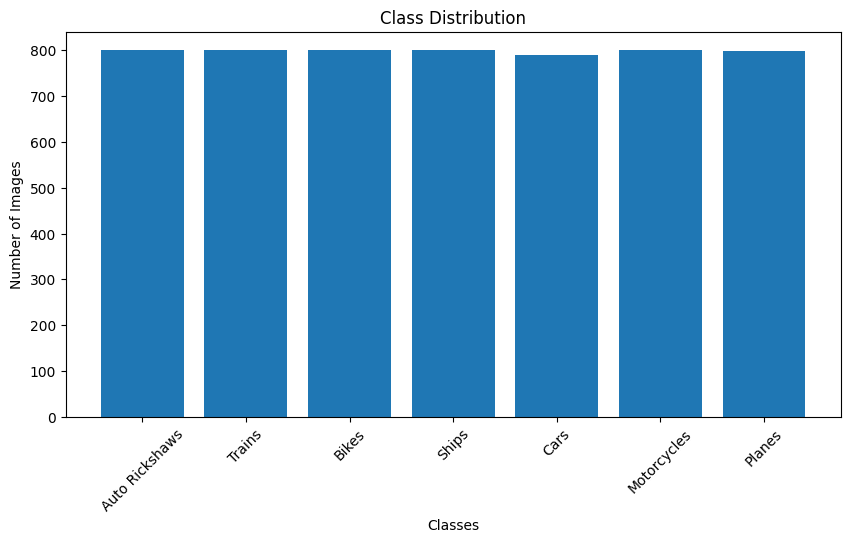

In [27]:
# Count number of images per class
class_counts = {}

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Display class distribution
print(class_counts)

# Visualize class distribution
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

Check Class Imbalance

In [28]:
import pandas as pd

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
print(df_counts.sort_values(by='Count', ascending=False))

            Class  Count
0  Auto Rickshaws    800
1          Trains    800
2           Bikes    800
3           Ships    800
5     Motorcycles    800
6          Planes    798
4            Cars    790


Display Images

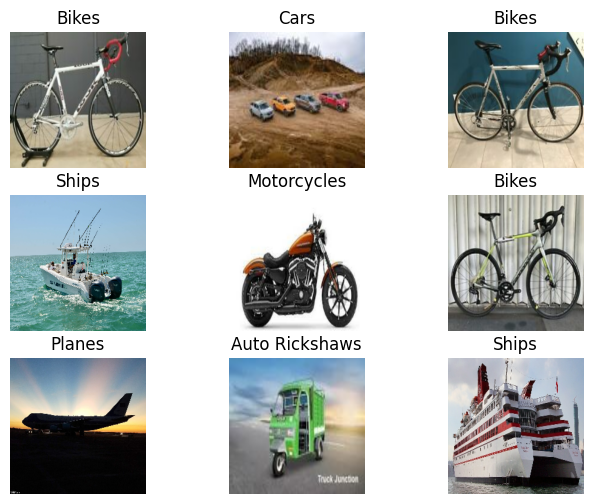

In [6]:
# Import visualization library
import matplotlib.pyplot as plt

# Display sample images from training dataset
plt.figure(figsize=(8,6))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis("off")

plt.show()

Baseline CNN Model Build

Simple CNN for image classification

*   Extracts features using Conv and Pooling layers
*   Dense layer for learning patterns
*   Dropout used to reduce overfitting
*   Softmax outputs class probabilities
*   Serves as performance baseline




In [7]:
# Import model API
from tensorflow.keras import models

# Define baseline CNN model
baseline_model = models.Sequential([
    tf.keras.Input(shape=(224,224,3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline

In [10]:
import tensorflow as tf

# Skip corrupted or invalid images during dataset loading
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())

# Apply same error handling to validation dataset
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [11]:
# Train baseline model on training dataset
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,  # Evaluate on validation data
    epochs=10                # Number of training epochs
)

Epoch 1/10
    123/Unknown 22s 177ms/step - accuracy: 0.3102 - loss: 1.9599

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


123/123 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.4456 - loss: 1.5067 - val_accuracy: 0.7169 - val_loss: 0.9679
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - accuracy: 0.7117 - loss: 0.8401 - val_accuracy: 0.8022 - val_loss: 0.6369
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 250ms/step - accuracy: 0.7899 - loss: 0.6146 - val_accuracy: 0.7963 - val_loss: 0.6194
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 60s 488ms/step - accuracy: 0.8308 - loss: 0.4924 - val_accuracy: 0.7777 - val_loss: 0.6193
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 27s 210ms/step - accuracy: 0.8642 - loss: 0.3938 - val_accuracy: 0.8125 - val_loss: 0.6000
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - accuracy: 0.9030 - loss: 0.2829 - val_accuracy: 0.8159 - val_loss: 0.5435
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9297 - loss: 0.2127 - val_accuracy: 0.8198 - val_loss: 0.5667
Epoch 8/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 457ms/step - accuracy: 0.9383 - loss: 0.1802 - val

Plot Baseline

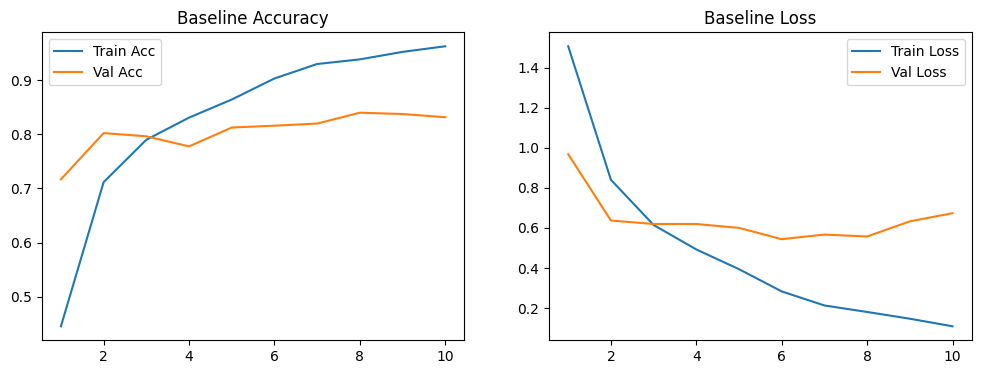

In [12]:
# Extract training and validation metrics
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']

# Define epoch range
epochs = range(1, len(acc)+1)

# Plot accuracy and loss curves
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.legend()
plt.title("Baseline Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.legend()
plt.title("Baseline Loss")

# Display plots
plt.show()

Predictions

In [13]:
# Import required libraries for evaluation
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Initialize lists to store true and predicted labels
y_true = []
y_pred = []

# Generate predictions on validation dataset
for images, labels in val_ds:
    preds = baseline_model.predict(images, verbose=0)  # Model predictions
    y_true.extend(labels.numpy())                      # True labels
    y_pred.extend(np.argmax(preds, axis=1))            # Predicted labels

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

Classification Report

In [14]:
# Display classification performance metrics
print("Baseline CNN Classification Report")

# Print precision, recall, F1-score for each class
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Baseline CNN Classification Report
                precision    recall  f1-score   support

Auto Rickshaws       0.81      0.79      0.80       128
         Bikes       1.00      0.94      0.97       122
          Cars       0.81      0.74      0.77       148
   Motorcycles       0.91      0.81      0.86       159
        Planes       0.86      0.85      0.86       157
         Ships       0.78      0.93      0.85       146
        Trains       0.71      0.76      0.73       161

      accuracy                           0.83      1021
     macro avg       0.84      0.83      0.83      1021
  weighted avg       0.84      0.83      0.83      1021



Baseline CNN Confusion Matrix

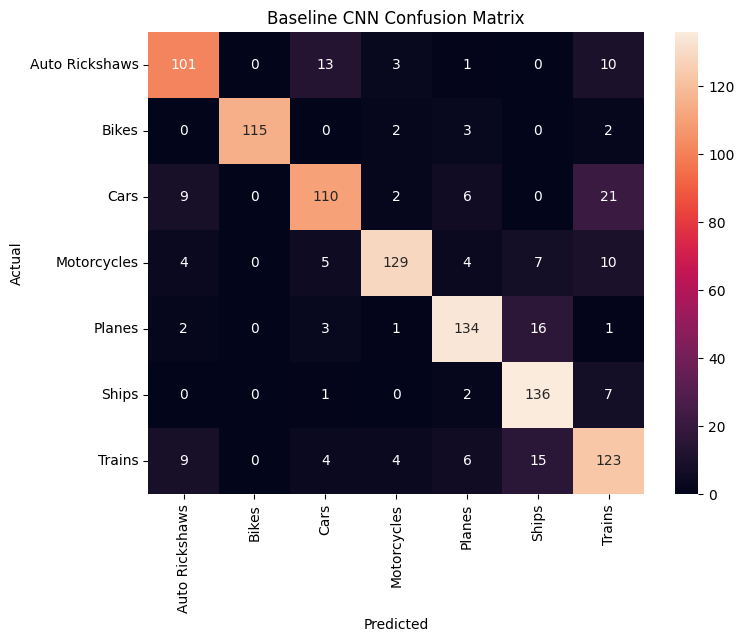

In [15]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

# Add labels and title
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display plot
plt.show()

MobileNetV2 (Frozen)

*   MobileNetV2 is a lightweight deep learning model for image classification
*   Designed to run efficiently on mobile and low-power devices
*   Uses depthwise separable convolutions to reduce computation
*   Introduces inverted residual blocks for better performance
*   Pre-trained on the ImageNet dataset (millions of images)



---
Pre-trained MobileNetV2 is used as a fixed feature extractor with a custom classification head










In [16]:
# Import pre-trained MobileNetV2 model
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 without top classification layer
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze pre-trained layers (no weight updates during training)
base_model.trainable = False

# Build custom classification head
inputs = layers.Input(shape=(224,224,3))
x = base_model(inputs, training=False)         # Extract features
x = layers.GlobalAveragePooling2D()(x)         # Reduce feature maps
x = layers.Dense(128, activation="relu")(x)    # Fully connected layer
x = layers.Dropout(0.5)(x)                     # Prevent overfitting
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)  # Output layer

# Create final model
model_frozen = models.Model(inputs, outputs)

# Compile model
model_frozen.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
model_frozen.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train Frozen Model

In [17]:
# Train MobileNetV2 (frozen) model
history_frozen = model_frozen.fit(
    train_ds,
    validation_data=val_ds,  # Validate performance on unseen data
    epochs=5                 # Train for limited epochs (transfer learning)
)

Epoch 1/5
    125/Unknown 60s 314ms/step - accuracy: 0.8258 - loss: 0.5182

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 391ms/step - accuracy: 0.9211 - loss: 0.2469 - val_accuracy: 0.9893 - val_loss: 0.0341
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 378ms/step - accuracy: 0.9768 - loss: 0.0760 - val_accuracy: 0.9892 - val_loss: 0.0409
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 214ms/step - accuracy: 0.9853 - loss: 0.0475 - val_accuracy: 0.9882 - val_loss: 0.0375
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 219ms/step - accuracy: 0.9869 - loss: 0.0394 - val_accuracy: 0.9931 - val_loss: 0.0246
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 478ms/step - accuracy: 0.9901 - loss: 0.0274 - val_accuracy: 0.9931 - val_loss: 0.0340


Plot Frozen Model

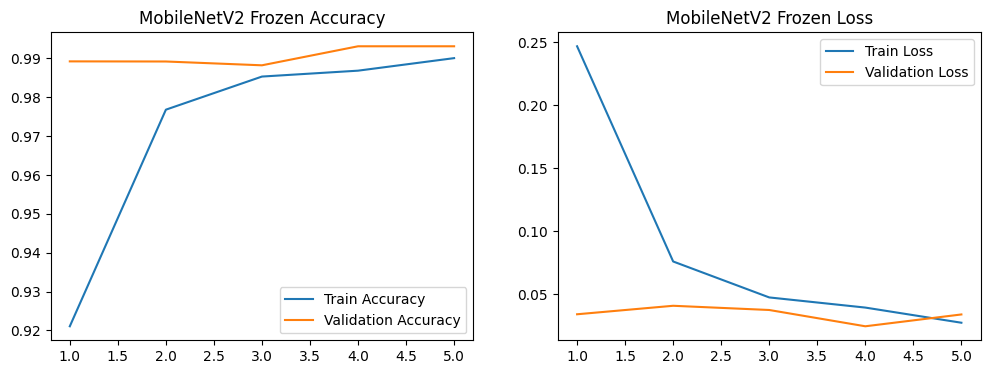

In [20]:
# Extract training history metrics
acc_frozen = history_frozen.history['accuracy']
val_acc_frozen = history_frozen.history['val_accuracy']
loss_frozen = history_frozen.history['loss']
val_loss_frozen = history_frozen.history['val_loss']

# epoch range
epochs = range(1, len(acc_frozen) + 1)

# Plot accuracy and loss curves
plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, acc_frozen, label='Train Accuracy')
plt.plot(epochs, val_acc_frozen, label='Validation Accuracy')
plt.legend()
plt.title("MobileNetV2 Frozen Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, loss_frozen, label='Train Loss')
plt.plot(epochs, val_loss_frozen, label='Validation Loss')
plt.legend()
plt.title("MobileNetV2 Frozen Loss")

# Display plots
plt.show()

Evaluation (Frozen Model)

MobileNetV2 Frozen Report
                precision    recall  f1-score   support

Auto Rickshaws       0.98      1.00      0.99       121
         Bikes       0.99      1.00      1.00       133
          Cars       0.99      0.99      0.99       149
   Motorcycles       0.99      0.98      0.99       159
        Planes       1.00      0.98      0.99       154
         Ships       0.99      1.00      0.99       150
        Trains       0.99      0.99      0.99       155

      accuracy                           0.99      1021
     macro avg       0.99      0.99      0.99      1021
  weighted avg       0.99      0.99      0.99      1021



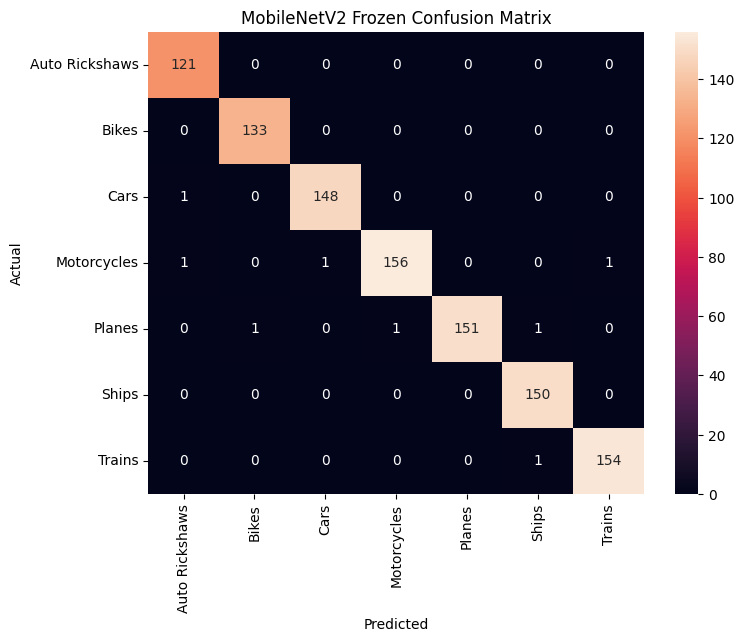

In [21]:
# Initialize lists for true and predicted labels
y_true_frozen = []
y_pred_frozen = []

# Generate predictions on validation dataset
for images, labels in val_ds:
    preds = model_frozen.predict(images, verbose=0)  # Model predictions
    y_true_frozen.extend(labels.numpy())             # True labels
    y_pred_frozen.extend(np.argmax(preds, axis=1))   # Predicted labels

# Convert to numpy arrays
y_true_frozen = np.array(y_true_frozen)
y_pred_frozen = np.array(y_pred_frozen)

# Print classification report
print("MobileNetV2 Frozen Report")
print(classification_report(y_true_frozen, y_pred_frozen, target_names=CLASS_NAMES))

# Compute confusion matrix
cm_frozen = confusion_matrix(y_true_frozen, y_pred_frozen)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_frozen, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

# Add labels and title
plt.title("MobileNetV2 Frozen Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display plot
plt.show()

Fine-Tuning MobileNetV2 (Partial Unfreezing)

*   Fine-tuning unfreezes top layers of MobileNetV2 to adapt pre-trained features to the new dataset.



Unfreeze Top Layers

In [22]:
# Unfreeze the pre-trained base model
base_model.trainable = True

# Freeze first N layers to retain low-level features
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile model with low learning rate (important for fine-tuning)
model_frozen.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train Fine-Tuned Model

In [23]:
# Train model after fine-tuning (partial unfreezing)
history_finetune = model_frozen.fit(
    train_ds,
    validation_data=val_ds,  # Evaluate performance during training
    epochs=5                 # Fine-tuning for few epochs (avoid overfitting)
)

Epoch 1/5
    124/Unknown 61s 288ms/step - accuracy: 0.9208 - loss: 0.2709

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


124/124 ━━━━━━━━━━━━━━━━━━━━ 76s 412ms/step - accuracy: 0.9321 - loss: 0.2215 - val_accuracy: 0.9931 - val_loss: 0.0281
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 35s 285ms/step - accuracy: 0.9649 - loss: 0.1123 - val_accuracy: 0.9922 - val_loss: 0.0346
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 32s 255ms/step - accuracy: 0.9774 - loss: 0.0740 - val_accuracy: 0.9931 - val_loss: 0.0361
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 29s 231ms/step - accuracy: 0.9798 - loss: 0.0557 - val_accuracy: 0.9922 - val_loss: 0.0354
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.9829 - loss: 0.0483 - val_accuracy: 0.9941 - val_loss: 0.0304


Plot Fine-Tuned

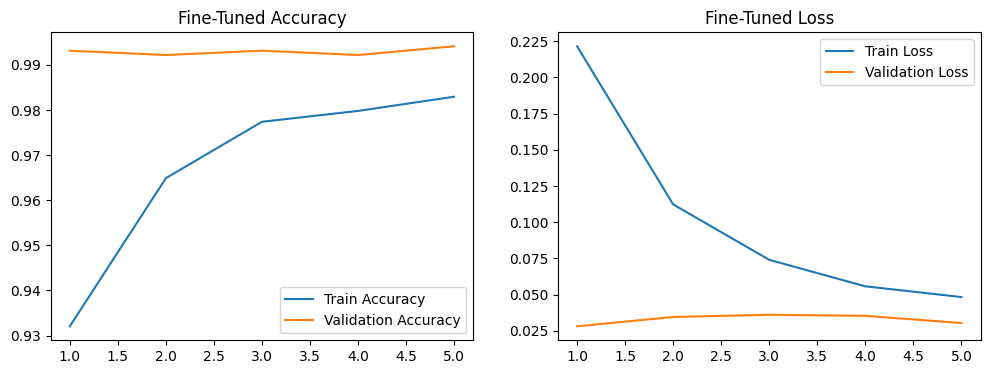

In [24]:
# Extract fine-tuning metrics
acc_finetuned = history_finetune.history['accuracy']
val_acc_finetuned = history_finetune.history['val_accuracy']
loss_finetuned = history_finetune.history['loss']
val_loss_finetuned = history_finetune.history['val_loss']

# Epoch range
epochs = range(1, len(acc_finetuned) + 1)

# Plot results
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc_finetuned, label='Train Accuracy')
plt.plot(epochs, val_acc_finetuned, label='Validation Accuracy')
plt.legend()
plt.title("Fine-Tuned Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss_finetuned, label='Train Loss')
plt.plot(epochs, val_loss_finetuned, label='Validation Loss')
plt.legend()
plt.title("Fine-Tuned Loss")

# Show plots
plt.show()

Final Evaluation (Fine-Tuned)

=== Fine-Tuned MobileNetV2 Report ===
                precision    recall  f1-score   support

Auto Rickshaws       0.98      0.99      0.99       130
         Bikes       0.99      1.00      1.00       137
          Cars       0.99      0.99      0.99       148
   Motorcycles       1.00      0.99      0.99       162
        Planes       1.00      0.99      1.00       146
         Ships       0.99      1.00      1.00       140
        Trains       0.99      0.99      0.99       158

      accuracy                           0.99      1021
     macro avg       0.99      0.99      0.99      1021
  weighted avg       0.99      0.99      0.99      1021



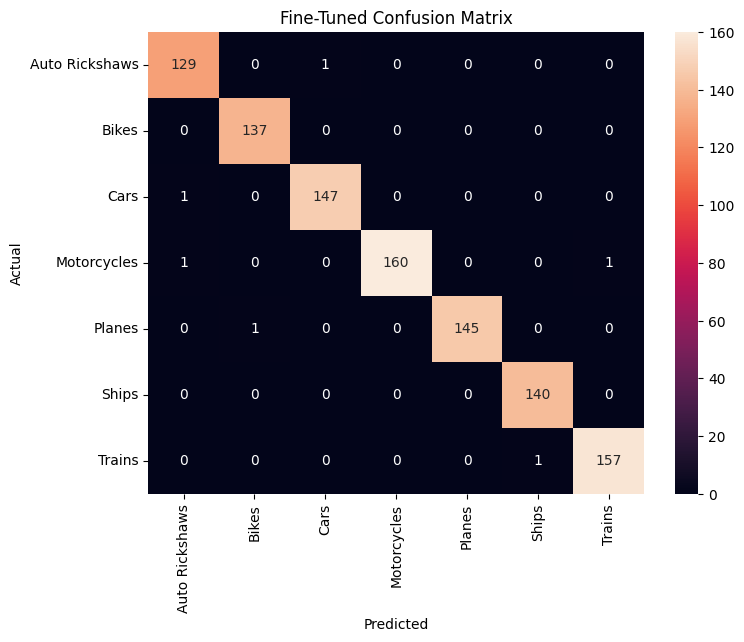

In [25]:
# Initialize lists
y_true_finetuned = []
y_pred_finetuned = []

# Generate predictions using fine-tuned model
for images, labels in val_ds:
    preds = model_frozen.predict(images, verbose=0)  # Predictions
    y_true_finetuned.extend(labels.numpy())          # True labels
    y_pred_finetuned.extend(np.argmax(preds, axis=1))# Predicted labels

# Convert to arrays
y_true_finetuned = np.array(y_true_finetuned)
y_pred_finetuned = np.array(y_pred_finetuned)

# Print classification report
print("=== Fine-Tuned MobileNetV2 Report ===")
print(classification_report(y_true_finetuned, y_pred_finetuned, target_names=CLASS_NAMES))

# Compute confusion matrix
cm_finetuned = confusion_matrix(y_true_finetuned, y_pred_finetuned)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm_finetuned, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

# Labels and title
plt.title("Fine-Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Show plot
plt.show()

ACCURACY COMPARISON

In [26]:
# Extract final validation accuracy from each model
baseline_acc = history_baseline.history['val_accuracy'][-1]
frozen_acc = history_frozen.history['val_accuracy'][-1]
finetuned_acc = history_finetune.history['val_accuracy'][-1]

# Print comparison results
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Frozen Accuracy: {frozen_acc:.3f}")
print(f"Fine-tuned Accuracy: {finetuned_acc:.3f}")

Baseline Accuracy: 0.832
Frozen Accuracy: 0.993
Fine-tuned Accuracy: 0.994


Prediction Function

In [33]:
# Function to visualize model predictions
def show_predictions(model, dataset, class_names, n=6):

    # Get a batch of images and labels
    images, labels = next(iter(dataset))

    # Generate predictions
    predictions = model.predict(images, verbose=0)

    # Create figure
    plt.figure(figsize=(15,5))

    # Loop through n samples
    for i in range(n):
        true_label = class_names[labels[i]]                  # Actual label
        pred_label = class_names[np.argmax(predictions[i])]  # Predicted label

        # Color based on correctness
        color = "green" if pred_label == true_label else "red"

        # Display image with prediction
        plt.subplot(1, n, i+1)
        plt.imshow(images[i])
        plt.title(f"Pred: {pred_label}\nGT: {true_label}", color=color)
        plt.axis("off")

    # Show results
    plt.show()

Baseline CNN Predictions

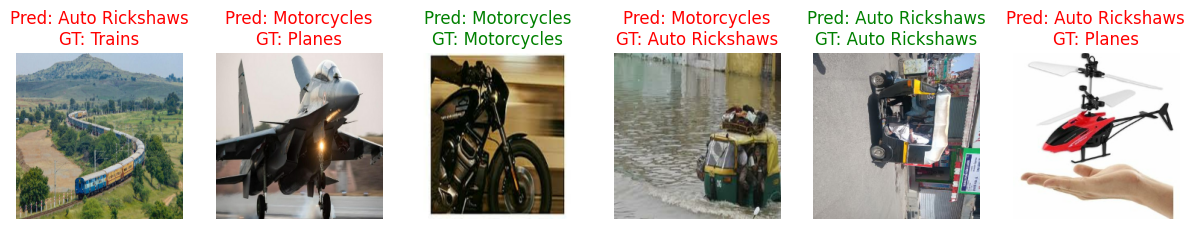

In [34]:
show_predictions(baseline_model, val_ds, CLASS_NAMES, n=6)

MobileNetV2 Frozen Predictions

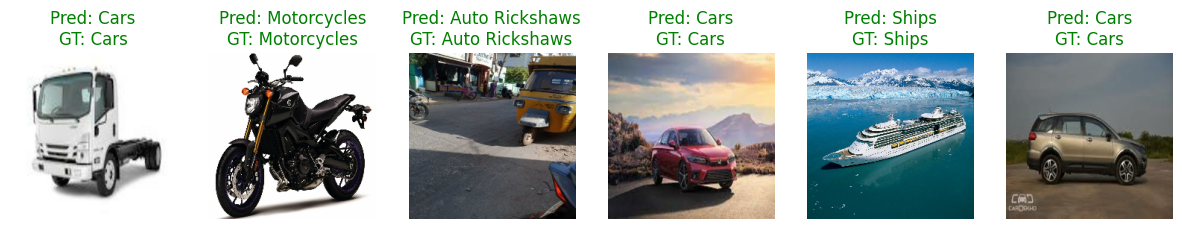

In [36]:
show_predictions(model_frozen, val_ds, CLASS_NAMES, n=6)


MobileNetV2 Fine Tuned Model -  Predictions

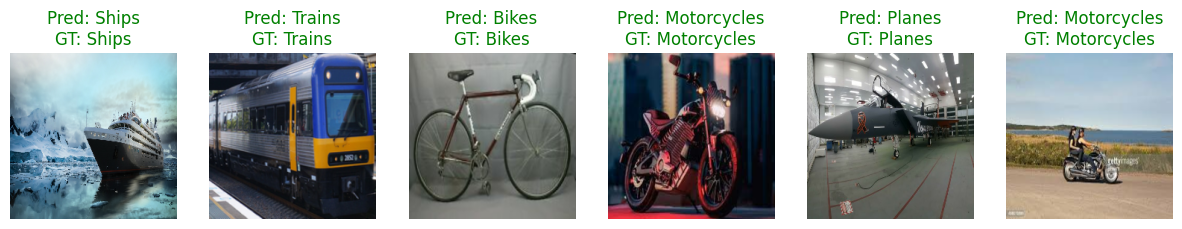

In [37]:
show_predictions(model_frozen, val_ds, CLASS_NAMES, n=6)  # fine-tuned also uses same model